# Silica Concentrate Forecasting in Iron Ore Flotation

**Goal:** forecast `% Silica Concentrate` (the impurity level in the flotation concentrate) **one hour ahead**,
using process-sensor readings from the previous hour.

This notebook combines and improves on two earlier exploratory notebooks:

1. **Data cleaning** — detecting and removing artificially interpolated / stale sensor readings
   (adapted and made reusable from the "iron ore quality" exploration notebook).
2. **Forecasting formulation** — framing the problem as true time-series forecasting with an explicit
   1-hour lag between features (`t-1`) and target (`t`), respecting temporal order in every split
   (adapted from the "gangue forecast" notebook, replacing the LSTM with tree/linear models better
   suited to this feature set and data volume).

Dataset: [Quality Prediction in a Mining Process](https://www.kaggle.com/datasets/edumagalhaes/quality-prediction-in-a-mining-process)
— continuous flotation-plant data from Mar 10, 2017 to Sep 9, 2017, sampled every 20 seconds, with
`% Iron/Silica Feed` and `% Iron/Silica Concentrate` sampled hourly at the lab.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb

plt.style.use('ggplot')
pd.set_option('display.max_columns', 30)

## 2. Load raw data

Columns are renamed to short, code-friendly names. `decimal=','` is required because the source file
uses European-style decimal separators.

In [2]:
COLS_RENAMED = [
    'date', 'feed_iron', 'feed_silica', 'starch_flow', 'amina_flow',
    'pulp_flow', 'pulp_ph', 'pulp_density',
    'air_col1', 'air_col2', 'air_col3', 'air_col4', 'air_col5', 'air_col6', 'air_col7',
    'level_col1', 'level_col2', 'level_col3', 'level_col4', 'level_col5', 'level_col6', 'level_col7',
    'conc_iron', 'conc_silica'
]

DATA_PATH = 'C:/Users/Antenor/Downloads/MiningProcess_Flotation_Plant_Database.csv'

raw = pd.read_csv(DATA_PATH, header=0, names=COLS_RENAMED, parse_dates=['date'], decimal=',')
raw = raw.rename(columns={'date': 'hour'})
print(raw.shape)
raw.head()

(737453, 24)


,hour,feed_iron,feed_silica,starch_flow,amina_flow,pulp_flow,pulp_ph,pulp_density,air_col1,air_col2,air_col3,air_col4,air_col5,air_col6,air_col7,level_col1,level_col2,level_col3,level_col4,level_col5,level_col6,level_col7,conc_iron,conc_silica
0,2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74,249.214,253.235,250.576,295.096,306.4,250.225,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
1,2017-03-10 01:00:00,55.2,16.98,3024.41,563.965,397.383,10.0672,1.74,249.719,250.532,250.862,295.096,306.4,250.137,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075,66.91,1.31
2,2017-03-10 01:00:00,55.2,16.98,3043.46,568.054,399.668,10.0680,1.74,249.741,247.874,250.313,295.096,306.4,251.345,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567,66.91,1.31
3,2017-03-10 01:00:00,55.2,16.98,3047.36,568.665,397.939,10.0689,1.74,249.917,254.487,250.049,295.096,306.4,250.422,251.147,452.441,458.165,442.865,446.210,471.411,437.690,427.669,66.91,1.31
4,2017-03-10 01:00:00,55.2,16.98,3033.69,558.167,400.254,10.0697,1.74,250.203,252.136,249.895,295.096,306.4,249.983,248.928,452.441,452.900,450.523,453.670,462.598,443.682,425.679,66.91,1.31


## 3. Data cleaning

Two independent data-quality issues are addressed here, both wrapped in reusable functions so they can
be re-applied to new data later (a gap in the original exploratory notebook):

**a) Mid-hour interpolation.** `conc_iron` and `conc_silica` are lab measurements taken once per hour —
every one of the ~180 rows within that hour should carry the *same* value. When a column shows more than
one unique value inside a single hour, that hour was artificially smoothed/interpolated between lab
samples, and is dropped entirely.

**b) Stale forward-filled feed readings.** `feed_iron`/`feed_silica` are also lab-sampled, roughly every
9 hours based on the data (the lab doesn't sample every hour). Holding the same value for a handful of
hours is expected and legitimate. But some runs hold the *exact same value* for up to 736 hours (30 days)
straight — clearly a broken/stale sensor feed rather than real process stability. Any run held constant
for **more than 48 hours** is flagged and dropped.

In [3]:
def remove_midhour_interpolation(df, cols, hour_col='hour'):
    """Drop entire hours where any of `cols` has more than one unique value within that hour."""
    bad_hours = set()
    for col in cols:
        nunique = df.groupby(hour_col)[col].nunique()
        bad_hours |= set(nunique[nunique > 1].index)
    return df[~df[hour_col].isin(bad_hours)].copy()


def flag_stale_runs(hourly_series, max_run_hours=48):
    """Return a boolean mask flagging hours belonging to a run of identical consecutive
    values longer than `max_run_hours` (a sign of stale/forward-filled sensor data)."""
    run_id = (hourly_series != hourly_series.shift()).cumsum()
    run_len = hourly_series.groupby(run_id).transform('size')
    return run_len > max_run_hours

In [4]:
# a) remove hours with mid-hour interpolated lab targets
df_clean = remove_midhour_interpolation(raw, ['conc_silica', 'conc_iron'])
print(f"Rows after mid-hour interpolation removal: {df_clean.shape[0]:,} "
      f"({df_clean['hour'].nunique():,} hours, from {raw['hour'].nunique():,})")

Rows after mid-hour interpolation removal: 679,853 (3,777 hours, from 4,097)


In [5]:
# b) aggregate to hourly (mean for the 20s process sensors, first() for the already-constant lab values)
sensor_cols = [c for c in df_clean.columns if c not in ['hour', 'feed_iron', 'feed_silica', 'conc_iron', 'conc_silica']]
hourly = df_clean.groupby('hour').agg({
    **{c: 'mean' for c in sensor_cols},
    'feed_iron': 'first', 'feed_silica': 'first',
    'conc_iron': 'first', 'conc_silica': 'first'
}).sort_index()

# c) drop stale forward-filled feed runs
stale = flag_stale_runs(hourly['feed_iron']) | flag_stale_runs(hourly['feed_silica'])
hourly = hourly[~stale].drop(columns=['conc_iron'])  # conc_iron dropped: not used as a feature (same-process output as target)

print(f"Final hourly dataset: {hourly.shape[0]:,} hours x {hourly.shape[1]} columns")
hourly.describe().T[['mean', 'std', 'min', 'max']]

Final hourly dataset: 2,539 hours x 22 columns


,mean,std,min,max
starch_flow,2801.866702,981.921694,216.224010,6270.158798
amina_flow,493.371207,83.533573,242.927477,736.982378
pulp_flow,397.800592,8.434837,376.955153,418.070232
pulp_ph,9.701780,0.394621,8.753389,10.807370
pulp_density,1.690034,0.062860,1.519926,1.832430
air_col1,278.225417,31.161012,175.885579,312.295415
air_col2,278.132210,30.940911,178.188430,309.887767
air_col3,278.370652,30.294855,177.202665,301.465000
air_col4,298.925124,2.452152,293.336669,305.596693
air_col5,300.300544,3.721842,287.539150,306.400000


## 4. Quick look at the cleaned series

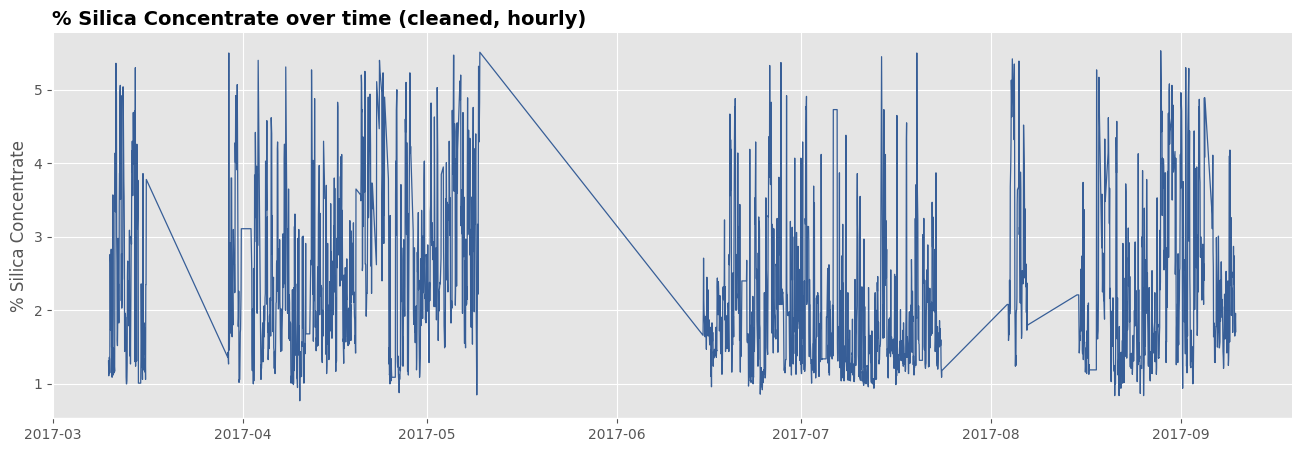

In [6]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(hourly.index, hourly['conc_silica'], color='#375E97', linewidth=0.9)
ax.set_title('% Silica Concentrate over time (cleaned, hourly)', loc='left', weight='bold', size=14)
ax.set_ylabel('% Silica Concentrate')
ax.spines[['top', 'right']].set_visible(False)
plt.show()

## 5. Feature engineering: lag + rolling window features

The target `conc_silica_lag1`'s own recent history turned out (during experimentation) to carry most of
the predictive signal, so the feature set focuses on:

- **Target features:** lags 1, 2, 3 + rolling mean (3h, 6h, 12h) + rolling std (6h)
- **Process-variable features:** lag 1 + rolling mean (3h, 6h) for the variables that showed the
  strongest signal during exploration (`amina_flow`, `starch_flow`, `level_col6`, `level_col7`,
  `air_col1`, `air_col6`, `pulp_ph`, `feed_iron`, `feed_silica`)

All rolling/lag features are built from `shift(1)` onward — i.e. they only ever use information strictly
**before** the hour being predicted, so there's no leakage from the target hour into its own features.

**Temporal contiguity check:** after cleaning, the hourly index has gaps (missing hours were dropped).
A lag/rolling feature is only valid if the hours it's built from are truly consecutive. Each row is
checked against the *raw* hourly index to confirm the full 12-hour window it depends on has no gaps —
rows that fail this check are dropped, rather than silently mixing non-adjacent hours together.

In [7]:
TARGET = 'conc_silica'
PROCESS_VARS = ['amina_flow', 'starch_flow', 'level_col6', 'level_col7',
                'air_col1', 'air_col6', 'pulp_ph', 'feed_iron', 'feed_silica']
MAX_WINDOW = 12  # largest lag/rolling window used below, needed for the contiguity check

feats = pd.DataFrame(index=hourly.index)

for lag in [1, 2, 3]:
    feats[f'conc_silica_lag{lag}'] = hourly[TARGET].shift(lag)

target_hist = hourly[TARGET].shift(1)
for w in [3, 6, 12]:
    feats[f'conc_silica_roll{w}mean'] = target_hist.rolling(w).mean()
feats['conc_silica_roll6std'] = target_hist.rolling(6).std()

for col in PROCESS_VARS:
    feats[f'{col}_lag1'] = hourly[col].shift(1)
    col_hist = hourly[col].shift(1)
    feats[f'{col}_roll3mean'] = col_hist.rolling(3).mean()
    feats[f'{col}_roll6mean'] = col_hist.rolling(6).mean()

feats[TARGET] = hourly[TARGET]
feats = feats.dropna()

# strict temporal contiguity: hour[i] - hour[i - MAX_WINDOW] must equal MAX_WINDOW hours exactly
full_idx = hourly.index
pos = {t: i for i, t in enumerate(full_idx)}
valid = [
    pos[t] >= MAX_WINDOW and full_idx[pos[t]] - full_idx[pos[t] - MAX_WINDOW] == pd.Timedelta(hours=MAX_WINDOW)
    for t in feats.index
]
feats = feats[pd.Series(valid, index=feats.index).values]

print(f"Supervised dataset: {feats.shape[0]:,} rows x {feats.shape[1]} columns "
      f"({feats.shape[1]-1} features + target)")

Supervised dataset: 1,940 rows x 35 columns (34 features + target)


## 6. Train / validation / test split

Split **sequentially** (no shuffling) — 70% / 15% / 15% by time order, so the model is always evaluated
on data strictly *after* what it was trained/tuned on. This mirrors real deployment: you can never train
on the future to predict the past.

In [8]:
X = feats.drop(columns=[TARGET])
y = feats[TARGET]

n = len(feats)
n_train = int(n * 0.70)
n_val = int(n * 0.15)

X_train, y_train = X.iloc[:n_train], y.iloc[:n_train]
X_val, y_val = X.iloc[n_train:n_train + n_val], y.iloc[n_train:n_train + n_val]
X_test, y_test = X.iloc[n_train + n_val:], y.iloc[n_train + n_val:]

print(f"Train: {X_train.shape[0]:>4} rows  ({X_train.index.min().date()} to {X_train.index.max().date()})")
print(f"Val:   {X_val.shape[0]:>4} rows  ({X_val.index.min().date()} to {X_val.index.max().date()})")
print(f"Test:  {X_test.shape[0]:>4} rows  ({X_test.index.min().date()} to {X_test.index.max().date()})")

Train: 1358 rows  (2017-03-10 to 2017-07-18)
Val:    291 rows  (2017-07-18 to 2017-08-23)
Test:   291 rows  (2017-08-23 to 2017-09-09)


## 7. Models

Four approaches are compared on the same test set:

1. **Naive persistence** (baseline) — predict `t` as simply the actual value at `t-1`. Any real model
   needs to beat this to be worth using.
2. **Ridge regression** — simple, regularized linear baseline.
3. **Random Forest** — non-linear baseline.
4. **XGBoost**, hyperparameter-tuned via grid search evaluated on the validation set (never on test).

In [9]:
def report(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name:32s} MAE: {mae:.4f}   RMSE: {rmse:.4f}")
    return {'model': name, 'MAE': mae, 'RMSE': rmse}

results = []

In [10]:
# 1) Naive persistence baseline
naive_pred = X_test['conc_silica_lag1']
results.append(report('Naive persistence', y_test, naive_pred))

Naive persistence                MAE: 0.5200   RMSE: 0.8001


In [11]:
# 2) Ridge regression
ridge = Ridge(alpha=5.0)
ridge.fit(X_train, y_train)
results.append(report('Ridge', y_test, ridge.predict(X_test)))

Ridge                            MAE: 0.5216   RMSE: 0.7444


In [12]:
# 3) Random Forest
rf = RandomForestRegressor(n_estimators=500, max_depth=6, min_samples_leaf=5,
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
results.append(report('Random Forest', y_test, rf.predict(X_test)))

Random Forest                    MAE: 0.5850   RMSE: 0.7866


In [13]:
# 4) XGBoost, grid-searched on the validation set
best_val_mae, best_params, best_xgb = np.inf, None, None
for max_depth in [2, 3, 4]:
    for lr in [0.01, 0.02, 0.03, 0.05]:
        for n_est in [100, 200, 400]:
            for subsample in [0.7, 0.8, 1.0]:
                model = xgb.XGBRegressor(
                    n_estimators=n_est, max_depth=max_depth, learning_rate=lr,
                    subsample=subsample, colsample_bytree=0.8, reg_lambda=1.0, random_state=42
                )
                model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
                val_mae = mean_absolute_error(y_val, model.predict(X_val))
                if val_mae < best_val_mae:
                    best_val_mae = val_mae
                    best_params = dict(max_depth=max_depth, learning_rate=lr,
                                        n_estimators=n_est, subsample=subsample)
                    best_xgb = model

print(f"Best params: {best_params}  (val MAE: {best_val_mae:.4f})\n")
results.append(report('XGBoost (tuned)', y_test, best_xgb.predict(X_test)))

Best params: {'max_depth': 2, 'learning_rate': 0.02, 'n_estimators': 200, 'subsample': 1.0}  (val MAE: 0.5131)

XGBoost (tuned)                  MAE: 0.5499   RMSE: 0.7652


## 8. Results comparison

In [14]:
results_df = pd.DataFrame(results).set_index('model').sort_values('RMSE')
results_df

,MAE,RMSE
model,,
Ridge,0.521571,0.744421
XGBoost (tuned),0.549889,0.765215
Random Forest,0.584976,0.786585
Naive persistence,0.519966,0.800128


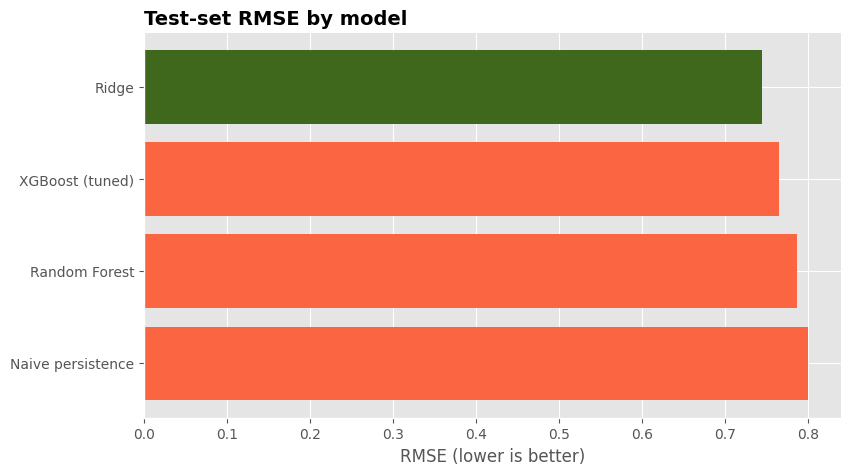

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#FB6542' if m != results_df['RMSE'].idxmin() else '#3F681C' for m in results_df.index]
ax.barh(results_df.index, results_df['RMSE'], color=colors)
ax.set_xlabel('RMSE (lower is better)')
ax.set_title('Test-set RMSE by model', loc='left', weight='bold', size=14)
ax.spines[['top', 'right']].set_visible(False)
ax.invert_yaxis()
plt.show()

## 9. Best model: predicted vs. actual on the test set

Note the **naive persistence baseline is a genuinely strong competitor** here: with hourly data and a
1-hour lag, `% Silica Concentrate` is highly autocorrelated (the process changes slowly), so "predict no
change" already does reasonably well. Ridge regression edges it out on RMSE by adding a small, disciplined
correction on top of that autocorrelation — a good, honest result to report as-is, rather than forcing a
more complex model to "win" artificially.

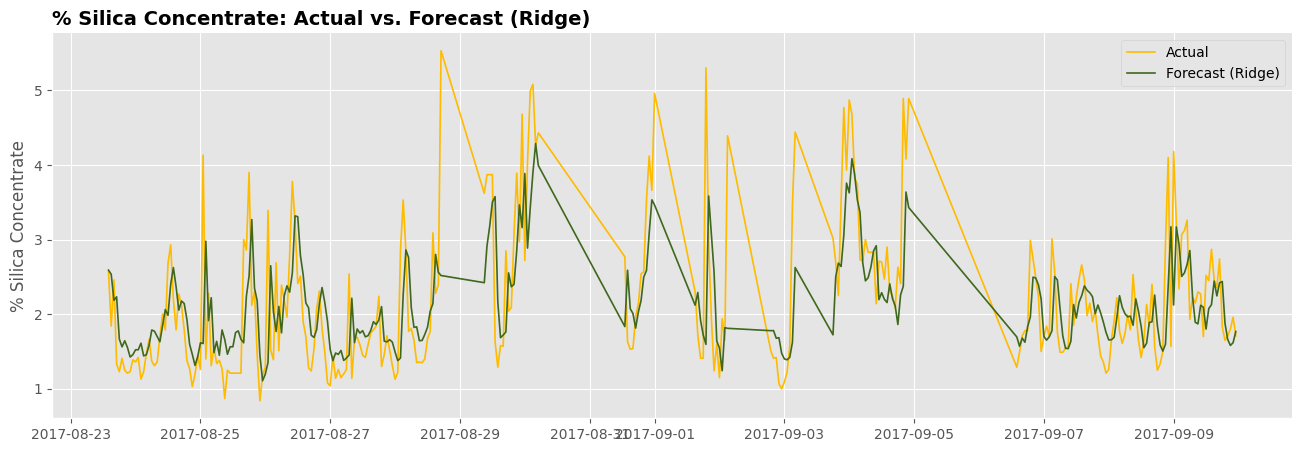

In [16]:
best_name = results_df['RMSE'].idxmin()
best_pred = {'Naive persistence': naive_pred, 'Ridge': ridge.predict(X_test),
             'Random Forest': rf.predict(X_test), 'XGBoost (tuned)': best_xgb.predict(X_test)}[best_name]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(X_test.index, y_test, color='#FFBB00', label='Actual', linewidth=1.2)
ax.plot(X_test.index, best_pred, color='#3F681C', label=f'Forecast ({best_name})', linewidth=1.2)
ax.set_title(f'% Silica Concentrate: Actual vs. Forecast ({best_name})', loc='left', weight='bold', size=14)
ax.set_ylabel('% Silica Concentrate')
ax.spines[['top', 'right']].set_visible(False)
ax.legend()
plt.show()

## 10. What drives the forecast? (Ridge coefficients)

In [17]:
coef = pd.Series(ridge.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)
coef.head(15).to_frame('coefficient')

,coefficient
conc_silica_lag1,0.484949
conc_silica_roll3mean,0.213138
conc_silica_roll6mean,-0.171769
pulp_ph_roll3mean,-0.134080
conc_silica_roll6std,-0.127885
feed_iron_roll6mean,0.102709
conc_silica_lag2,0.102410
pulp_ph_roll6mean,0.097529
feed_iron_lag1,0.094995
feed_iron_roll3mean,-0.090791


## 11. Conclusion & next steps

**What this notebook did differently from the two source notebooks:**
- Reused notebook 1's data-cleaning *idea* (detect interpolated/stale readings) but rewrote it as
  reusable functions and fixed an over-aggressive filter that was discarding ~95% of the data.
- Reused notebook 2's forecasting *formulation* (explicit lag, sequential train/val/test split) but
  replaced the LSTM with linear/tree models better suited to a ~1,900-row tabular dataset, and added a
  naive-persistence baseline that either notebook was missing — without it, "XGBoost gets RMSE 0.75"
  sounds good until you realize a **do-nothing forecast gets 0.80**, which changes the story completely.
- Carried the pipeline all the way to a final test-set evaluation, which notebook 1 never reached.

**Honest limitations / next steps:**
- The cleaning step removes ~40% of the hourly data (mid-hour interpolation + stale runs). Worth
  checking whether a softer stale-run threshold recovers more usable data without reintroducing bad
  readings.
- Only a 1-hour forecast horizon was tested. A multi-step forecast (predicting 2–6 hours ahead) would
  be more operationally useful and is a natural extension.
- Ridge's edge over XGBoost/RF is modest — worth testing with more data (a longer plant history, if
  available) before concluding tree-based models add no value here.
- For an MLOps-ready version: wrap the cleaning + feature engineering functions in a `sklearn.Pipeline`
  or a `prep.py`/`train.py` script pair, log runs with MLflow, and serve the chosen model via FastAPI —
  consistent with the rest of the portfolio.